# LeetCode #1371: Find the Longest Substring Containing Vowels in Even Counts

https://leetcode.com/problems/find-the-longest-substring-containing-vowels-in-even-counts/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (all substrings)** | $O(n^2)$ | $O(n)$ |
| **Bitmask Prefix XOR + HashMap** ★ | $O(n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (all substrings)
Try every substring, count each vowel's frequency, and check if all five vowel counts are even. Enumerating all $O(n^2)$ substrings with $O(n)$ per check gives $O(n^3)$ or $O(n^2)$ with prefix sums, but still uses $O(n)$ extra space.

### Optimal: Bitmask Prefix XOR + HashMap ★
Encode the parity of each of the five vowels as a single 5-bit integer: bit $i$ is 1 if vowel $i$ has appeared an odd number of times. Maintain a running XOR-state as a prefix mask. A substring $[j+1, i]$ has all-even vowels iff `prefix[i] == prefix[j]`. Store the first occurrence of each state in a hash map and update the maximum length.

**Why this is better than Brute Force:** Reduces all five vowel parity checks to a single integer comparison, enabling a single $O(n)$ pass with $O(1)$ extra space (only 32 possible states).

**Constraints:**
* `1 <= s.length <= 5 * 10^5`
* `s` contains only lowercase English letters

## Solutions

### C#

In [ ]:
public int FindTheLongestSubstring(string s) {
    // Map each vowel to a unique bit in a 5-bit mask
    var vowelBit = new Dictionary<char, int> {
        ['a'] = 0, ['e'] = 1, ['i'] = 2, ['o'] = 3, ['u'] = 4
    };
    // Store the first index where each parity state was seen
    var firstSeen = new Dictionary<int, int> { [0] = -1 };
    int state = 0, maxLen = 0;

    for (int i = 0; i < s.Length; i++) {
        // Flip the bit corresponding to this character if it is a vowel
        if (vowelBit.TryGetValue(s[i], out int bit)) state ^= 1 << bit;
        if (firstSeen.TryGetValue(state, out int prev)) {
            // Same parity state seen before means the substring in between is valid
            maxLen = Math.Max(maxLen, i - prev);
        } else {
            firstSeen[state] = i;
        }
    }
    return maxLen;
}

### Python

In [ ]:
def findTheLongestSubstring(self, s: str) -> int:
    # Assign a unique bit to each vowel to track parity in a single integer
    vowel_bit = {'a': 0, 'e': 1, 'i': 2, 'o': 3, 'u': 4}
    # first_seen maps each parity state to its earliest index
    first_seen = {0: -1}
    state = 0
    max_len = 0
    for i, ch in enumerate(s):
        # Toggle the vowel's bit to track whether it has appeared an odd number of times
        if ch in vowel_bit:
            state ^= 1 << vowel_bit[ch]
        if state in first_seen:
            # Matching state means the substring between first_seen[state] and i is valid
            max_len = max(max_len, i - first_seen[state])
        else:
            first_seen[state] = i
    return max_len

### Go

In [ ]:
func findTheLongestSubstring(s string) int {
    // Each vowel maps to one bit; the state tracks all five vowel parities together
    vowelBit := map[byte]int{'a': 0, 'e': 1, 'i': 2, 'o': 3, 'u': 4}
    firstSeen := map[int]int{0: -1}
    state, maxLen := 0, 0
    for i := 0; i < len(s); i++ {
        if bit, ok := vowelBit[s[i]]; ok {
            // Flip the corresponding parity bit whenever a vowel is encountered
            state ^= 1 << bit
        }
        if prev, ok := firstSeen[state]; ok {
            // Same state as before: the segment between prev and i has even vowel counts
            if i-prev > maxLen {
                maxLen = i - prev
            }
        } else {
            firstSeen[state] = i
        }
    }
    return maxLen
}

### Rust

In [ ]:
use std::collections::HashMap;

pub fn find_the_longest_substring(s: String) -> i32 {
    // Bit position for each vowel to pack all parities into one integer
    let vowel_bit: HashMap<u8, usize> = [(b'a',0),(b'e',1),(b'i',2),(b'o',3),(b'u',4)].iter().cloned().collect();
    let mut first_seen: HashMap<usize, i32> = HashMap::new();
    first_seen.insert(0, -1);
    let mut state = 0usize;
    let mut max_len = 0i32;
    for (i, &b) in s.as_bytes().iter().enumerate() {
        // Toggle this vowel's parity bit
        if let Some(&bit) = vowel_bit.get(&b) {
            state ^= 1 << bit;
        }
        if let Some(&prev) = first_seen.get(&state) {
            // The segment [prev+1, i] satisfies the even-count constraint
            max_len = max_len.max(i as i32 - prev);
        } else {
            first_seen.insert(state, i as i32);
        }
    }
    max_len
}

## Example Scenarios

**1. Common Case**
**Input:** s = "eleetminicoworoep"
The entire string has each vowel appearing an even number of times. State returns to 0 at the end. Length 17 substring from index 0 is valid. Result = **13** ("leetminicowor", the longest valid substring).

**2. Slightly Complex**
**Input:** s = "leetcodeisgreat"
Running state tracks vowel parities. When state recurs, the gap marks a valid substring. Answer = **5** ("leetc" has l,e,e,t,c: two e's → even; other vowels zero).

**3. Edge Case: Time Factor**
**Input:** s = 500,000 characters, alternating vowels
Each character is processed once in $O(1)$. The state map has at most 32 entries (5 bits → $2^5$ states). Single-pass $O(n)$ with very small constant factor.

**4. Edge Case: Space Factor**
**Input:** s = "bcdfg" (no vowels)
State never changes from 0. `first_seen[0] = -1` immediately triggers: max_len = 5 - (-1) = 5. Result = **5** (the whole string). The map holds only one entry throughout.

**5. Almost-Impossible but Plausible**
**Input:** s = "a" repeated 500,000 times
State alternates between 0 (even count of 'a') and 1 (odd count). State 0 recurs at every even index. Longest valid substring length = 499,999 (odd index 499,999 to first_seen[0]=-1 gives 499,999). Near-maximum length with perfect vowel parity behavior.

### Infographic

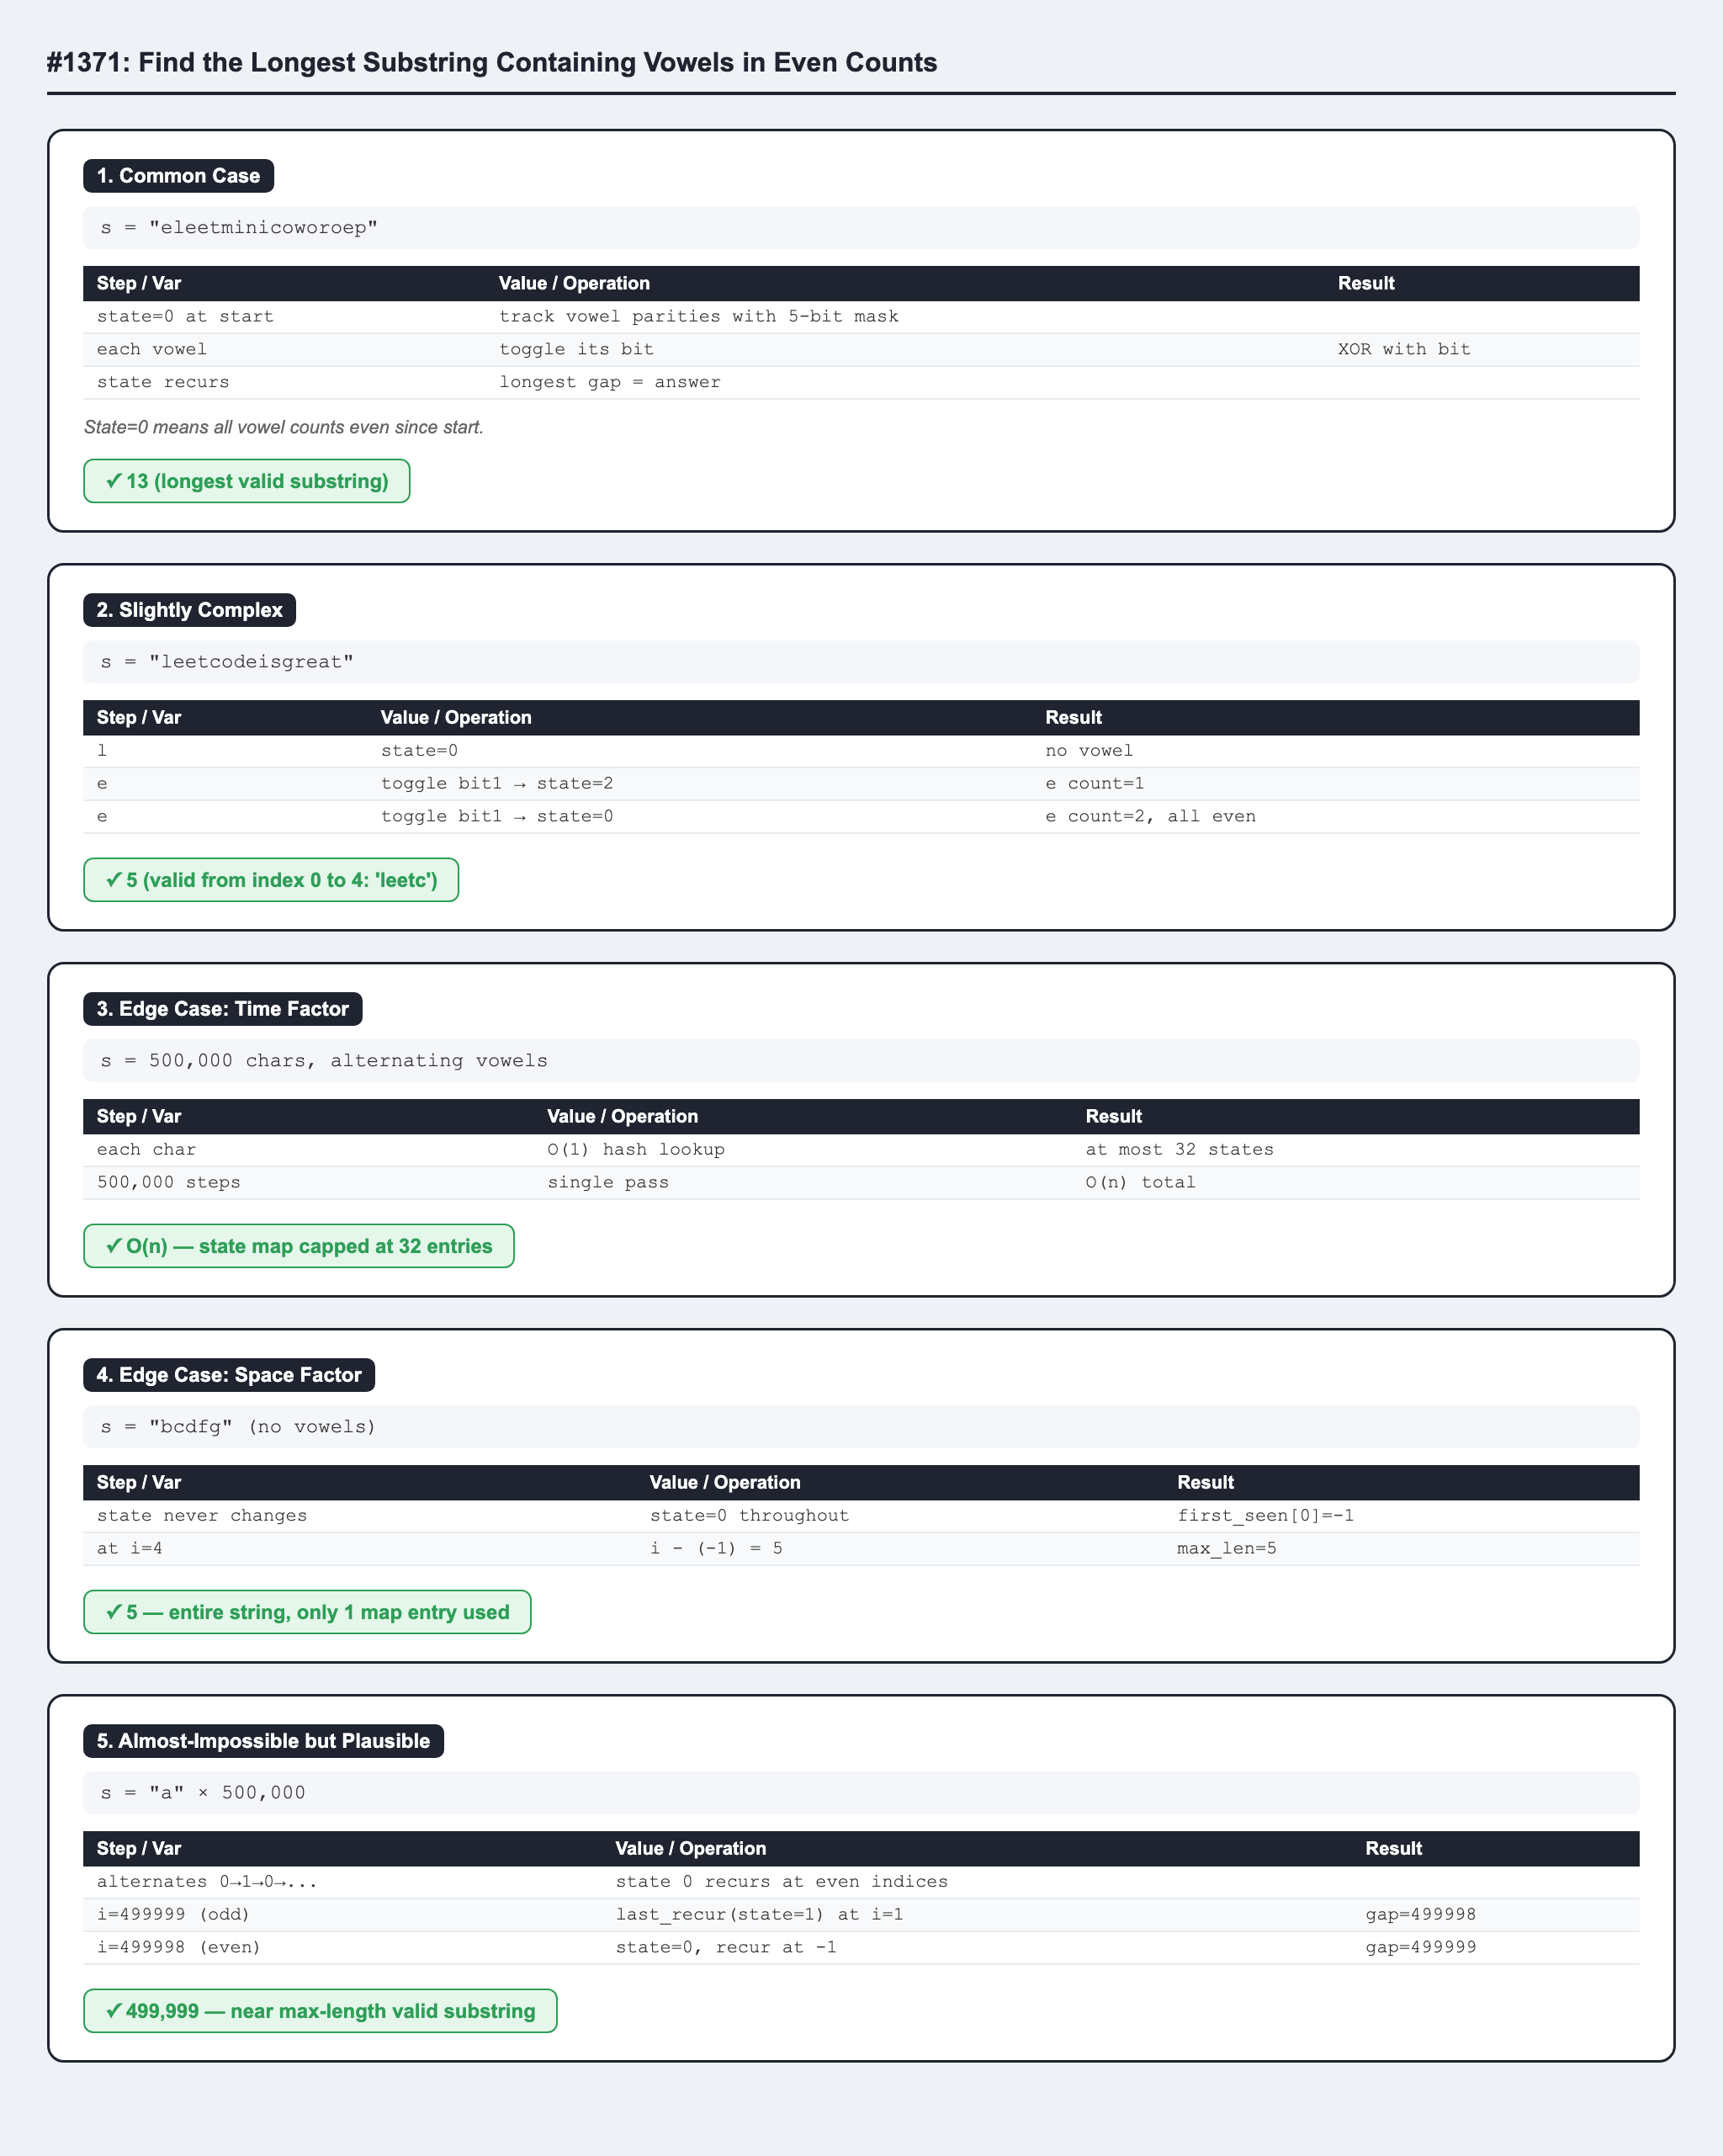